In [ ]:
!python3 src/preprocessing/to-bronze/download_raw_data.py --savee
!python3 src/preprocessing/to-silver/unify_audio.py --savee
!python3 src/preprocessing/to-silver/enhance_audio.py --savee
!python3 src/preprocessing/to-silver/chunk_audio.py --savee

!python3 src/preprocessing/to-gold/01_extract_metadata.py --savee
!python3 src/preprocessing/to-gold/02_extract_acoustic_features.py --savee
!python3 src/preprocessing/to-gold/03_extract_features_vggish.py --savee
!python3 src/preprocessing/to-gold/04_extract_wav2vec2_features.py --savee
!python3 src/preprocessing/to-gold/05_extract_hubert_features.py --savee
!python3 src/preprocessing/to-gold/06_extract_mel_spectrograms.py --savee

In [ ]:
!python3 src/models/evaluate_cross_corpus.py --model-type crnn --model-path "temp/CRNN_HuBERT_best_model.pth" --run-name "CRNN_CrossCorpus_SAVEE" --hubert-features

!python3 src/models/evaluate_cross_corpus.py --model-type hubert --model-path "temp/HuBERT_Finetune_best_model.pth" --run-name "HuBERT_CrossCorpus_SAVEE"

Оцінка моделі crnn на пристрої: cuda
Завантаження базових ознак з data/gold/features.parquet...
Додавання ознак HuBERT...
Додавання пре-обчислених Mel-спектрограм...
Об'єднаний датасет готовий! Розмірність (рядки, колонки): (981, 12903)
Inference CRNN: 100%|███████████████████████████| 16/16 [00:00<00:00, 36.00it/s]

--- Результати Cross-Corpus оцінки (CRNN_CrossCorpus_SAVEE) ---
              precision    recall  f1-score   support

         ang       0.32      0.47      0.38       119
         fea       0.23      0.32      0.27       138
         hap       0.26      0.44      0.32       131
         neu       0.34      0.05      0.08       287
         sad       0.28      0.32      0.30       177
         sur       0.17      0.19      0.18       129

    accuracy                           0.26       981
   macro avg       0.27      0.30      0.25       981
weighted avg       0.28      0.26      0.23       981

Графіки збережено у папку temp/ з префіксом CrossCorpus_CRNN_CrossCorpus_S

## Результати падіння точності для: CRNN_CrossCorpus_SAVEE

### Матриця плутанини на SAVEE

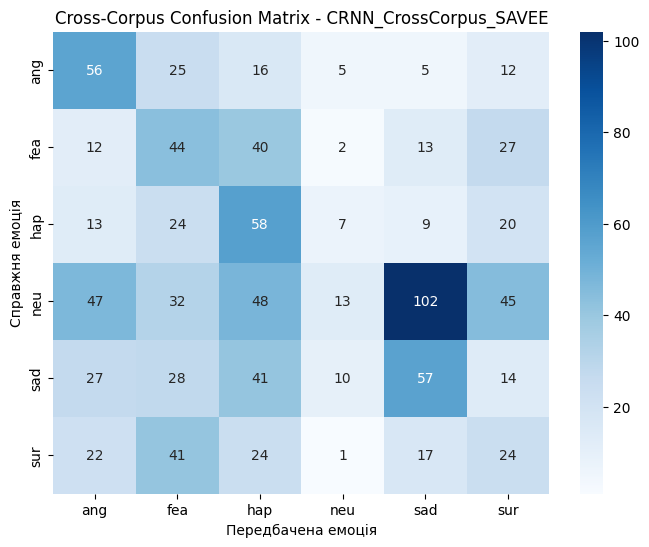

### ROC-AUC на SAVEE

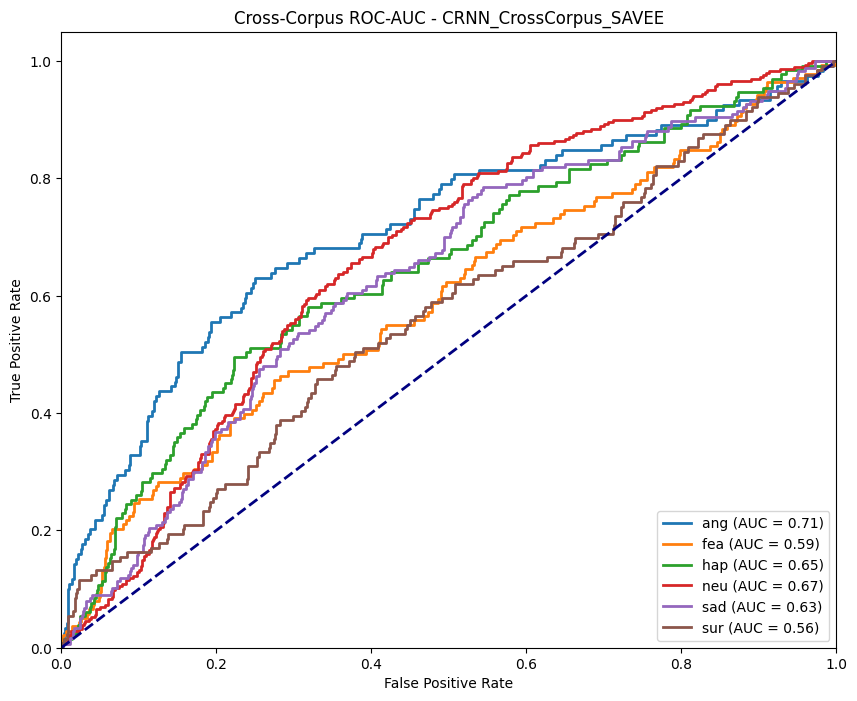

---

## Результати падіння точності для: HuBERT_CrossCorpus_SAVEE

### Матриця плутанини на SAVEE

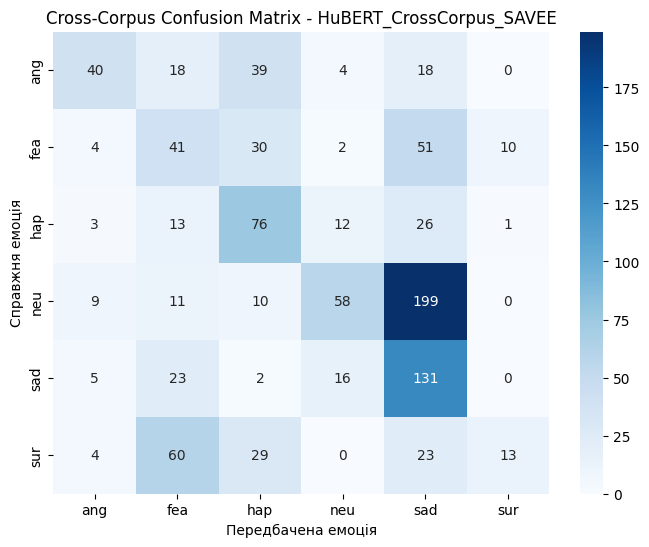

### ROC-AUC на SAVEE

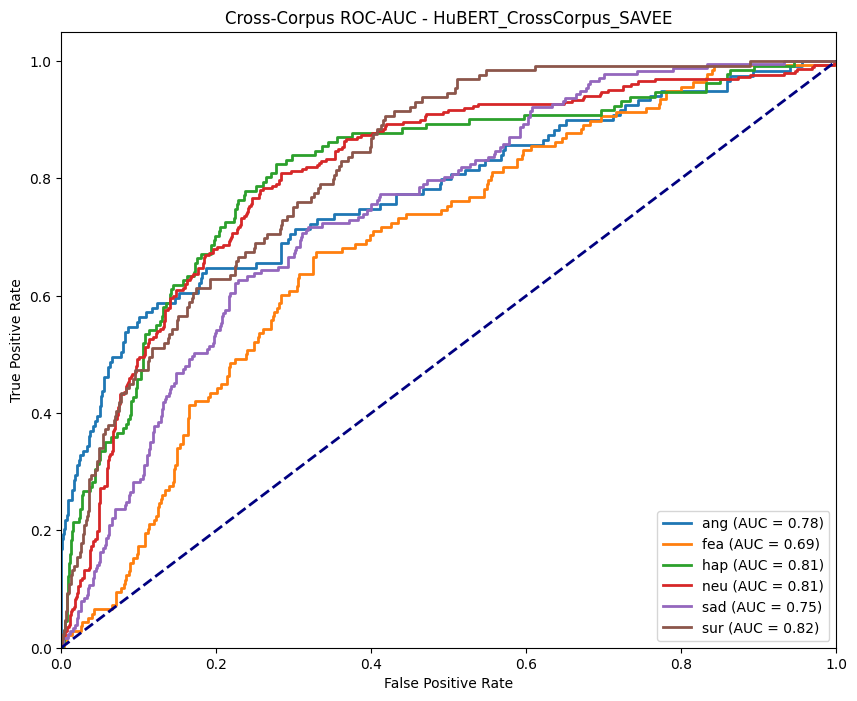

---

In [8]:
from IPython.display import Image, display, Markdown
import os

run_names = ["CRNN_CrossCorpus_SAVEE", "HuBERT_CrossCorpus_SAVEE"]

for run in run_names:
    if os.path.exists(f"temp/CrossCorpus_{run}_cm.png"):
        display(Markdown(f"## Результати падіння точності для: {run}"))
        
        display(Markdown("### Матриця плутанини на SAVEE"))
        display(Image(filename=f"temp/CrossCorpus_{run}_cm.png"))
        
        display(Markdown("### ROC-AUC на SAVEE"))
        display(Image(filename=f"temp/CrossCorpus_{run}_roc.png"))
        display(Markdown("---"))